In [ ]:
# a. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredLogarithmicError

In [ ]:
# b. Upload / Access the Dataset

In [2]:
PATH_TO_DATA = 'http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv'
data = pd.read_csv(PATH_TO_DATA, header=None)
print("Dataset Loaded Successfully!")
print(data.head())

Dataset Loaded Successfully!
        0         1         2         3         4         5         6    \
0 -0.112522 -2.827204 -3.773897 -4.349751 -4.376041 -3.474986 -2.181408   
1 -1.100878 -3.996840 -4.285843 -4.506579 -4.022377 -3.234368 -1.566126   
2 -0.567088 -2.593450 -3.874230 -4.584095 -4.187449 -3.151462 -1.742940   
3  0.490473 -1.914407 -3.616364 -4.318823 -4.268016 -3.881110 -2.993280   
4  0.800232 -0.874252 -2.384761 -3.973292 -4.338224 -3.802422 -2.534510   

        7         8         9    ...       131       132       133       134  \
0 -1.818286 -1.250522 -0.477492  ...  0.792168  0.933541  0.796958  0.578621   
1 -0.992258 -0.754680  0.042321  ...  0.538356  0.656881  0.787490  0.724046   
2 -1.490659 -1.183580 -0.394229  ...  0.886073  0.531452  0.311377 -0.021919   
3 -1.671131 -1.333884 -0.965629  ...  0.350816  0.499111  0.600345  0.842069   
4 -1.783423 -1.594450 -0.753199  ...  1.148884  0.958434  1.059025  1.371682   

        135       136       137       1

In [3]:
# Dataset Shape

print("Shape of the dataset:", data.shape)

Shape of the dataset: (4998, 141)


In [4]:
# Split features and target

features = data.drop(140, axis=1)
target = data[140]

In [5]:
# Split train and test data (stratified)

x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, stratify=target)

In [6]:
# Train only on normal data (label = 1)

train_index = y_train[y_train == 1].index
train_data = x_train.loc[train_index]

In [7]:
# Data Normalization using MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
x_train_scaled = scaler.fit_transform(train_data.copy())
x_test_scaled = scaler.transform(x_test.copy())

In [ ]:
# c & d. Build Autoencoder Model (Encoder + Decoder)

In [8]:
class AutoEncoder(Model):
    def __init__(self, output_units, latent_dim=8):
        super().__init__()
        # Encoder Network
        self.encoder = Sequential([
            Dense(64, activation='relu'),
            Dropout(0.1),
            Dense(32, activation='relu'),
            Dropout(0.1),
            Dense(16, activation='relu'),
            Dropout(0.1),
            Dense(latent_dim, activation='relu')
        ])
        # Decoder Network
        self.decoder = Sequential([
            Dense(16, activation='relu'),
            Dropout(0.1),
            Dense(32, activation='relu'),
            Dropout(0.1),
            Dense(64, activation='relu'),
            Dropout(0.1),
            Dense(output_units, activation='sigmoid')
        ])
    
    def call(self, inputs):
        encoded = self.encoder(inputs)
        decoded = self.decoder(encoded)
        return decoded

In [ ]:
# e. Compile the Model

In [9]:
autoencoder = AutoEncoder(output_units=x_train_scaled.shape[1])
autoencoder.compile(optimizer=Adam(learning_rate=0.001),loss='msle', metrics=['mse'])

In [10]:
# Train the Model

epochs = 20
history = autoencoder.fit(
    x_train_scaled,
    x_train_scaled,
    epochs=epochs,
    batch_size=512,
    validation_data=(x_test_scaled, x_test_scaled),
    verbose=1
)

Epoch 1/20
5/5 [==============================] - 1s 48ms/step - loss: 0.0109 - mse: 0.0242 - val_loss: 0.0135 - val_mse: 0.0316
Epoch 2/20
5/5 [==============================] - 0s 12ms/step - loss: 0.0105 - mse: 0.0233 - val_loss: 0.0133 - val_mse: 0.0311
Epoch 3/20
5/5 [==============================] - 0s 16ms/step - loss: 0.0097 - mse: 0.0217 - val_loss: 0.0132 - val_mse: 0.0308
Epoch 4/20
5/5 [==============================] - 0s 12ms/step - loss: 0.0088 - mse: 0.0195 - val_loss: 0.0125 - val_mse: 0.0292
Epoch 5/20
5/5 [==============================] - 0s 14ms/step - loss: 0.0078 - mse: 0.0172 - val_loss: 0.0120 - val_mse: 0.0281
Epoch 6/20
5/5 [==============================] - 0s 14ms/step - loss: 0.0069 - mse: 0.0152 - val_loss: 0.0114 - val_mse: 0.0267
Epoch 7/20
5/5 [==============================] - 0s 14ms/step - loss: 0.0062 - mse: 0.0137 - val_loss: 0.0109 - val_mse: 0.0255
Epoch 8/20
5/5 [==============================] - 0s 16ms/step - loss: 0.0058 - mse: 0.0128 - val

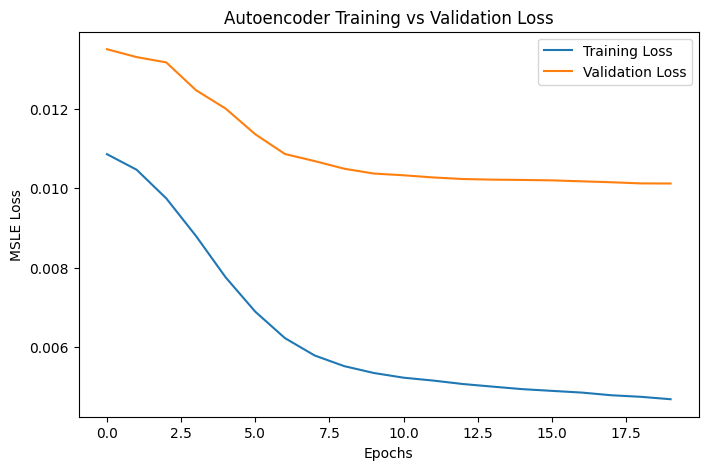

In [11]:
# Plot Training History

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSLE Loss')
plt.title('Autoencoder Training vs Validation Loss')
plt.legend()
plt.show()

In [12]:
# Find Threshold for Anomaly Detection

def find_threshold(model, x_train_scaled):
    reconstructions = model.predict(x_train_scaled)
    reconstruction_errors = tf.keras.losses.msle(reconstructions, x_train_scaled)
    threshold = np.mean(reconstruction_errors.numpy()) + np.std(reconstruction_errors.numpy())
    return threshold

In [13]:
# Predict Anomalies

def get_predictions(model, x_test_scaled, threshold):
    predictions = model.predict(x_test_scaled)
    errors = tf.keras.losses.msle(predictions, x_test_scaled)
    anomaly_mask = pd.Series(errors.numpy()) > threshold
    preds = anomaly_mask.map(lambda x: 0.0 if x else 1.0)  # 0 = anomaly, 1 = normal
    return preds

In [14]:
# Determine threshold

threshold = find_threshold(autoencoder, x_train_scaled)
print(f"Threshold for anomaly detection: {threshold}")

73/73 [==============================] - 0s 1ms/step
Threshold for anomaly detection: 0.010207840486042608


In [15]:
# Get Predictions and Accuracy

predictions = get_predictions(autoencoder, x_test_scaled, threshold)
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy:.4f}")

32/32 [==============================] - 0s 1ms/step
Model Accuracy: 0.9470
